In [1]:
import os
import numpy as np
from dipy.viz import regtools
from dipy.data import fetch_stanford_hardi
from dipy.data.fetcher import fetch_syn_data
from dipy.io.image import (load_nifti, save_nifti)
from dipy.align.imaffine import (transform_centers_of_mass,
                                 AffineMap,
                                 MutualInformationMetric,
                                 AffineRegistration)
from dipy.align.transforms import (TranslationTransform3D,
                                   RigidTransform3D,
                                   AffineTransform3D)
from dipy.align.imwarp import SymmetricDiffeomorphicRegistration
from dipy.align.metrics import CCMetric
from dipy.align import affine_registration, register_dwi_to_template
import matplotlib.pyplot as plt

C:\Users\rafae\AppData\Local\Temp\ipykernel_23344\1860084283.py:3: UserWarning: You do not have FURY installed. Some visualization functions might not work for you. Please install or upgrade FURY using pip install -U fury. For detailed installation instructions visit: https://fury.gl/
  from dipy.viz import regtools


# Load data

In [2]:
pth_ref = 'C:\\Users\\rafae\\Data\\Templates\\JHU-ICBM-FA-2mm.nii.gz'
pth_rois = 'C:\\Users\\rafae\\Data\\Templates\\JHU-ICBM-labels-2mm.nii.gz'
ref_fa, ref_affine, ref_img = load_nifti(pth_ref, return_img=True)
ref_roi, roi_affine, roi_img = load_nifti(pth_rois, return_img=True)

In [3]:
np.shape(ref_fa)

(91, 109, 91)

In [4]:
pth_main = 'C:\\Users\\rafae\\Data\\CTIhuman\\sub-10\\CTImetrics_gs_c2\\'

pth_data = pth_main + 'FA.nii'

fa, fa_affine, fa_img = load_nifti(pth_data, return_img=True)

In [5]:
np.shape(fa)

(84, 84, 60)

# Plot initial data

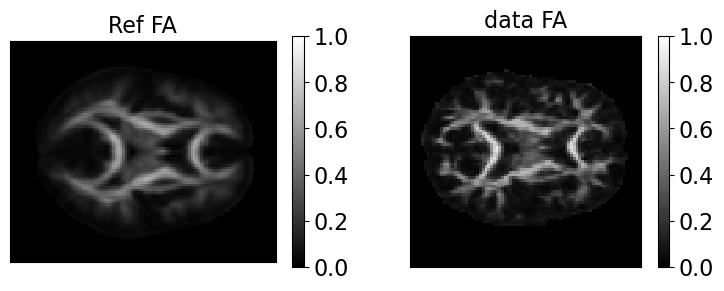

In [6]:
fig1, ax = plt.subplots(1, 2, figsize=(9, 3),
                        subplot_kw={'xticks': [], 'yticks': []})

fig1.subplots_adjust(hspace=0.03, wspace=0.1)
cax0 = ax.flat[0].imshow(ref_fa[:, :, 41],
                  origin='lower', cmap='gray',
                  vmin=0, vmax=1, interpolation='nearest')
ax.flat[0].set_title('Ref FA', fontsize=16)

cax1 = ax.flat[1].imshow(fa[:, :, 30],
                  origin='lower', cmap='gray',
                  vmin=0, vmax=1, interpolation='nearest')
ax.flat[1].set_title('data FA', fontsize=16)

cbar = fig1.colorbar(cax0, ax=ax.flat[0])
cbar.ax.tick_params(labelsize=16) 

cbar = fig1.colorbar(cax1, ax=ax.flat[1])
cbar.ax.tick_params(labelsize=16) 



In [7]:
ref_affine

array([[  -2.,    0.,    0.,   90.],
       [   0.,    2.,    0., -126.],
       [   0.,    0.,    2.,  -72.],
       [   0.,    0.,    0.,    1.]])

In [8]:
roi_affine

array([[  -2.,    0.,    0.,   90.],
       [   0.,    2.,    0., -126.],
       [   0.,    0.,    2.,  -72.],
       [   0.,    0.,    0.,    1.]])

In [9]:
fa_affine

array([[-2.50000000e+00,  0.00000000e+00,  2.15000001e-12,
         1.05000000e+02],
       [ 0.00000000e+00,  2.50000000e+00, -3.70449990e-11,
        -9.45000000e+01],
       [ 2.15000001e-12,  3.70449990e-11,  2.50000000e+00,
        -6.37500000e+01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

# Let's register data (affine)

In [10]:
pipeline = ["center_of_mass", "translation", "rigid", "affine"]

fa_reg0, reg_affine = affine_registration(
    fa,
    ref_fa,
    moving_affine=fa_affine,
    static_affine=ref_affine,
    nbins=32,
    metric='MI',
    pipeline=pipeline)

[2026-07-11 18:28:36][dipy] INFO: Default level_iters have been updated to [1000, 500, 100] for performance improvement. Identical results are expected. In case of any discrepancy, you can revert to the previous default by setting level_iters=[10000, 1000, 100].
[2026-07-11 18:28:36][dipy] INFO: ➞ Running center_of_mass step from affine registration...
[2026-07-11 18:28:36][dipy] INFO: ➞ Running translation step from affine registration...
[2026-07-11 18:28:38][dipy] INFO: ➞ Running rigid step from affine registration...
[2026-07-11 18:28:40][dipy] INFO: ➞ Running affine step from affine registration...


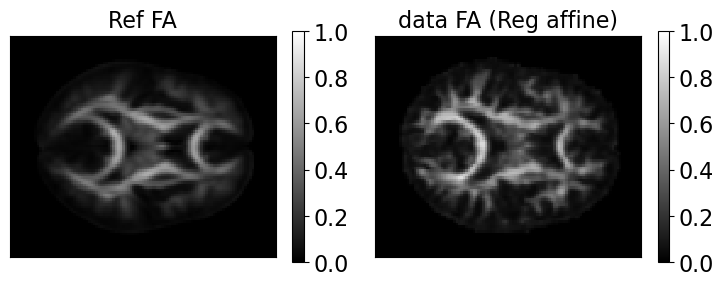

In [11]:
fig1, ax = plt.subplots(1, 2, figsize=(9, 3),
                        subplot_kw={'xticks': [], 'yticks': []})

fig1.subplots_adjust(hspace=0.03, wspace=0.1)
cax0 = ax.flat[0].imshow(ref_fa[:, :, 41],
                  origin='lower', cmap='gray',
                  vmin=0, vmax=1, interpolation='nearest')
ax.flat[0].set_title('Ref FA', fontsize=16)

cax1 = ax.flat[1].imshow(fa_reg0[:, :, 41],
                  origin='lower', cmap='gray',
                  vmin=0, vmax=1, interpolation='nearest')
ax.flat[1].set_title('data FA (Reg affine)', fontsize=16)

cbar = fig1.colorbar(cax0, ax=ax.flat[0])
cbar.ax.tick_params(labelsize=16) 

cbar = fig1.colorbar(cax1, ax=ax.flat[1])
cbar.ax.tick_params(labelsize=16) 

C:\Users\rafae\AppData\Local\Temp\ipykernel_23344\325396762.py:1: UserWarning: Pass ['slice_index', 'slice_type', 'ltitle', 'rtitle', 'fname'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  regtools.overlay_slices(ref_fa, fa_reg0, None, 2,


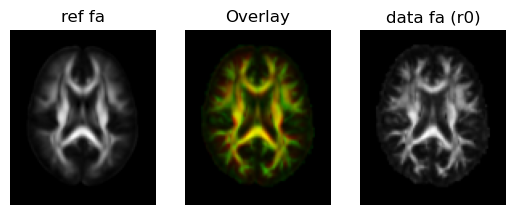

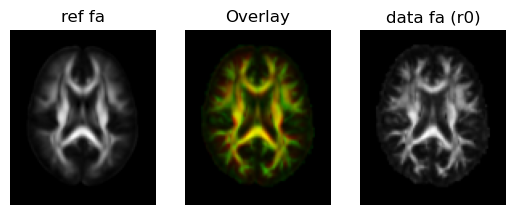

In [12]:
regtools.overlay_slices(ref_fa, fa_reg0, None, 2,
                        "ref fa", "data fa (r0)", "resampled_0.png")
#regtools.overlay_slices(ref_fa, fa_affine, None, 1,
#                        "ref fa", "xformed_img", "resampled_0.png")

In [13]:
reg_affine

array([[ 9.92725635e-01, -1.99686481e-02,  2.11059031e-02,
        -2.20882024e+00],
       [ 1.42420606e-02,  1.05618733e+00, -1.63373524e-01,
         2.53085296e+01],
       [ 7.52112672e-03,  1.58075037e-01,  9.49854259e-01,
         4.65875516e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

# Symmetric Diffeomorphic Registration

C:\Users\rafae\AppData\Local\Temp\ipykernel_23344\1345136148.py:3: UserWarning: Pass ['domain_grid_shape', 'domain_grid2world', 'codomain_grid_shape', 'codomain_grid2world'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  affine_map = AffineMap(reg_affine,


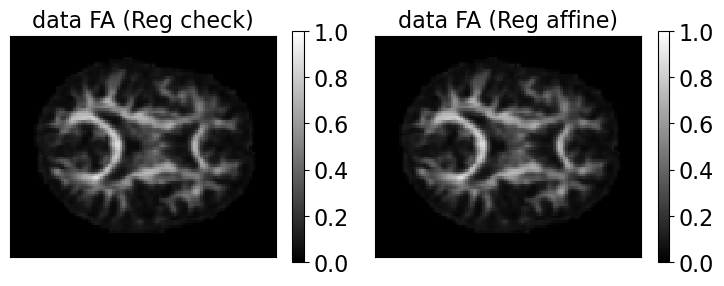

In [14]:
# check if inital registration is working fine

affine_map = AffineMap(reg_affine,
                       ref_fa.shape, ref_affine,
                       fa.shape, fa_affine)
fa_reg0_check = affine_map.transform(fa)




fig1, ax = plt.subplots(1, 2, figsize=(9, 3),
                        subplot_kw={'xticks': [], 'yticks': []})

fig1.subplots_adjust(hspace=0.03, wspace=0.1)
cax0 = ax.flat[0].imshow(fa_reg0_check[:, :, 41],
                  origin='lower', cmap='gray',
                  vmin=0, vmax=1, interpolation='nearest')
ax.flat[0].set_title('data FA (Reg check)', fontsize=16)

cax1 = ax.flat[1].imshow(fa_reg0[:, :, 41],
                  origin='lower', cmap='gray',
                  vmin=0, vmax=1, interpolation='nearest')
ax.flat[1].set_title('data FA (Reg affine)', fontsize=16)

cbar = fig1.colorbar(cax0, ax=ax.flat[0])
cbar.ax.tick_params(labelsize=16) 

cbar = fig1.colorbar(cax1, ax=ax.flat[1])
cbar.ax.tick_params(labelsize=16) 

C:\Users\rafae\AppData\Local\Temp\ipykernel_23344\2267601636.py:1: UserWarning: Pass ['slice_index', 'slice_type', 'ltitle', 'rtitle', 'fname'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  regtools.overlay_slices(fa_reg0_check, fa_reg0, None, 2,


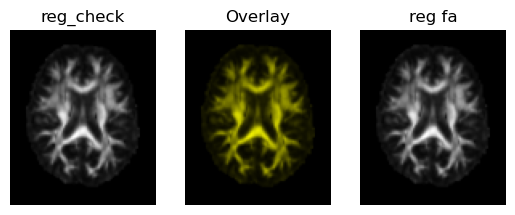

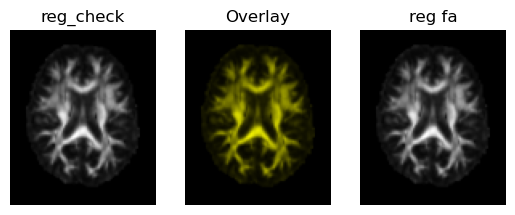

In [15]:
regtools.overlay_slices(fa_reg0_check, fa_reg0, None, 2,
                        "reg_check", "reg fa", "resampled_0.png")

In [16]:
metric = CCMetric(3)
level_iters = [10, 10, 5]
sdr = SymmetricDiffeomorphicRegistration(metric, level_iters)

C:\Users\rafae\AppData\Local\Temp\ipykernel_23344\1032817396.py:3: UserWarning: Pass ['level_iters'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sdr = SymmetricDiffeomorphicRegistration(metric, level_iters)


In [17]:
mapping = sdr.optimize(ref_fa, fa, ref_affine, fa_affine, reg_affine)

[2026-07-11 18:29:42][dipy] INFO: Creating scale space from the moving image. Levels: 3. Sigma factor: 0.200000.
[2026-07-11 18:29:42][dipy] INFO: Creating scale space from the static image. Levels: 3. Sigma factor: 0.200000.
[2026-07-11 18:29:42][dipy] INFO: Optimizing level 2


C:\Users\rafae\AppData\Local\Temp\ipykernel_23344\3030796809.py:1: UserWarning: Pass ['static_grid2world', 'moving_grid2world', 'prealign'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  mapping = sdr.optimize(ref_fa, fa, ref_affine, fa_affine, reg_affine)


[2026-07-11 18:29:43][dipy] INFO: Optimizing level 1
[2026-07-11 18:29:45][dipy] INFO: Optimizing level 0


In [18]:
fa_reg = mapping.transform(fa)

C:\Users\rafae\AppData\Local\Temp\ipykernel_23344\323559694.py:1: UserWarning: Pass ['slice_index', 'slice_type', 'ltitle', 'rtitle', 'fname'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  regtools.overlay_slices(ref_fa, fa_reg, None, 2,


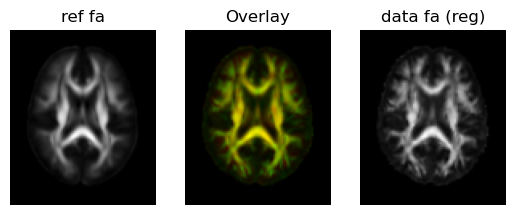

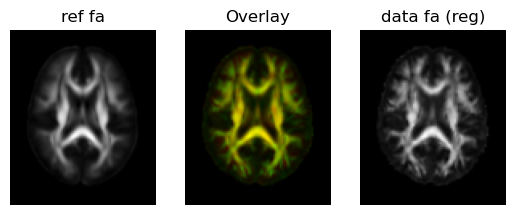

In [19]:
regtools.overlay_slices(ref_fa, fa_reg, None, 2,
                        "ref fa", "data fa (reg)", "resampled_0.png")

# Register ROIS to DWI

In [20]:
roi = mapping.transform_inverse(np.double(ref_roi), interpolation='nearest')

C:\Users\rafae\AppData\Local\Temp\ipykernel_23344\1075764960.py:1: UserWarning: Pass ['slice_index', 'slice_type', 'ltitle', 'rtitle'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  regtools.overlay_slices(fa, roi, None, 2,


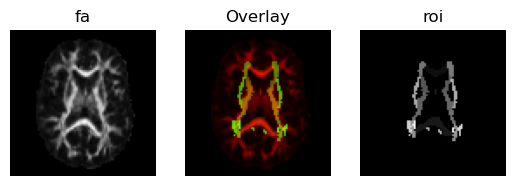

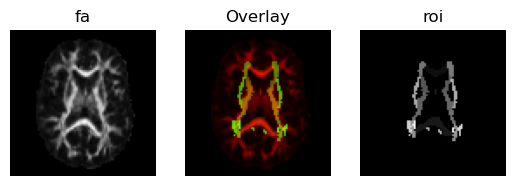

In [21]:
regtools.overlay_slices(fa, roi, None, 2,
                        "fa", "roi")

In [22]:
pth_data = pth_main + 'ROIs.nii'
save_nifti(pth_data, roi, fa_affine)

In [23]:
pth_main

'C:\\Users\\rafae\\Data\\CTIhuman\\sub-10\\CTImetrics_gs_c2\\'

# Register maps to template

In [24]:
# diffusivities

pth_data = pth_main + 'AD.nii'
ad, d_affine = load_nifti(pth_data)
ad_reg = mapping.transform(ad)

pth_data = pth_main + 'RD.nii'
rd, d_affine = load_nifti(pth_data)
rd_reg = mapping.transform(rd)

pth_data = pth_main + 'MD.nii'
md, fa_affine = load_nifti(pth_data)
md_reg = mapping.transform(md)

In [27]:
outpath = pth_main + 'RegData\\' 
os.mkdir(outpath)

In [28]:
# save diffusivities
pth_data = outpath + 'FA.nii'
save_nifti(pth_data, fa_reg, ref_affine)

pth_data = outpath + 'AD.nii'
save_nifti(pth_data, ad_reg, ref_affine)

pth_data = outpath + 'RD.nii'
save_nifti(pth_data, rd_reg, ref_affine)

pth_data = outpath + 'MD.nii'
save_nifti(pth_data, md_reg, ref_affine)

In [29]:
# total kurtosis time diffusivities

pth_data = pth_main + 'AKT.nii'
ak, d_affine = load_nifti(pth_data)
ak_reg = mapping.transform(ak)

pth_data = pth_main + 'RKT.nii'
rk, d_affine = load_nifti(pth_data)
rk_reg = mapping.transform(rk)

pth_data = pth_main + 'MKT.nii'
mk, fa_affine = load_nifti(pth_data)
mk_reg = mapping.transform(mk)

# save
pth_data = outpath + 'AK.nii'
save_nifti(pth_data, ak_reg, ref_affine)

pth_data = outpath + 'RK.nii'
save_nifti(pth_data, rk_reg, ref_affine)

pth_data = outpath + 'MK.nii'
save_nifti(pth_data, mk_reg, ref_affine)

In [30]:
# micro kurtosis time diffusivities

pth_data = pth_main + 'AKTi.nii'
ak, d_affine = load_nifti(pth_data)
ak_reg = mapping.transform(ak)

pth_data = pth_main + 'RKTi.nii'
rk, d_affine = load_nifti(pth_data)
rk_reg = mapping.transform(rk)

pth_data = pth_main + 'MKTi.nii'
mk, fa_affine = load_nifti(pth_data)
mk_reg = mapping.transform(mk)

# save
pth_data = outpath + 'uAK.nii'
save_nifti(pth_data, ak_reg, ref_affine)

pth_data = outpath + 'uRK.nii'
save_nifti(pth_data, rk_reg, ref_affine)

pth_data = outpath + 'uMK.nii'
save_nifti(pth_data, mk_reg, ref_affine)

In [31]:
# variance kurtosis time diffusivities

pth_data = pth_main + 'AKTv.nii'
ak, d_affine = load_nifti(pth_data)
ak_reg = mapping.transform(ak)

pth_data = pth_main + 'RKTv.nii'
rk, d_affine = load_nifti(pth_data)
rk_reg = mapping.transform(rk)

pth_data = pth_main + 'MKTv.nii'
mk, fa_affine = load_nifti(pth_data)
mk_reg = mapping.transform(mk)

# save
pth_data = outpath + 'vAK.nii'
save_nifti(pth_data, ak_reg, ref_affine)

pth_data = outpath + 'vRK.nii'
save_nifti(pth_data, rk_reg, ref_affine)

pth_data = outpath + 'vMK.nii'
save_nifti(pth_data, mk_reg, ref_affine)

In [32]:
# cti pa sources
pth_data = pth_main + 'KANISO.nii'
kani, d_affine = load_nifti(pth_data)
kani_reg = mapping.transform(kani)

pth_data = pth_main + 'KISO.nii'
kiso, d_affine = load_nifti(pth_data)
kiso_reg = mapping.transform(kiso)

pth_data = pth_main + 'KINTRA.nii'
kint, fa_affine = load_nifti(pth_data)
kint_reg = mapping.transform(kint)

pth_data = pth_main + 'KTOTAL.nii'
ktot, fa_affine = load_nifti(pth_data)
ktot_reg = mapping.transform(ktot)

pth_data = pth_main + 'Cov_ss_n.nii'
cov, fa_affine = load_nifti(pth_data)
cov_reg = mapping.transform(cov)

# save
pth_data = outpath + 'KANISO.nii'
save_nifti(pth_data, kani_reg, ref_affine)

pth_data = outpath + 'KISO.nii'
save_nifti(pth_data, kiso_reg, ref_affine)

pth_data = outpath + 'KINTRA.nii'
save_nifti(pth_data, kint_reg, ref_affine)

pth_data = outpath + 'KTOTAL.nii'
save_nifti(pth_data, ktot_reg, ref_affine)

pth_data = outpath + 'COV_ss_n.nii'
save_nifti(pth_data, cov_reg, ref_affine)


In [34]:
# OP calculation (this was done after manuscript revision)
def compute_OP(kani, fa, background_value=0.0):
    """
    Computes the Order Parameter (OP) from K_aniso and FA.
    
    Parameters:
    -----------
    kani : ndarray (Nx, Ny, Nz)
        Anisotropic kurtosis map.
    fa : ndarray (Nx, Ny, Nz)
        Fractional anisotropy map.
    background_value : float
        The value assigned to OP where K_aniso is <= 0.
        
    Returns:
    --------
    op_map : ndarray (Nx, Ny, Nz)
        OP map strictly bounded between [0, 1].
    """
    
    # Clean FA and Kani maps
    fa_clean = np.clip(fa, 0.0, 1.0)
    kani_clean = np.maximum(kani, 0.0) 
    
    # Compute numerator and denominator of OP equation
    numerator = 2.4 * (fa_clean ** 2)
    denominator = kani_clean * (3.0 - 2.0 * (fa_clean ** 2))
    
    # Create a mask to avoid dividing by zero where K_aniso is near zero
    valid_mask = kani_clean > 1e-8
    
    # Initialize OP with the background value
    op_map = np.full_like(kani, background_value, dtype=float)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        op_sq = np.divide(numerator, denominator, out=op_map, where=valid_mask)
        
    op_map[valid_mask] = np.sqrt(op_sq[valid_mask])
    
    # 6. Final safety clip to ensure OP does not exceed 1.0 
    # (Happens if noise causes macroscopic FA to artificially exceed microscopic FA)
    op_map = np.clip(op_map, 0.0, 1.0)
    
    return op_map

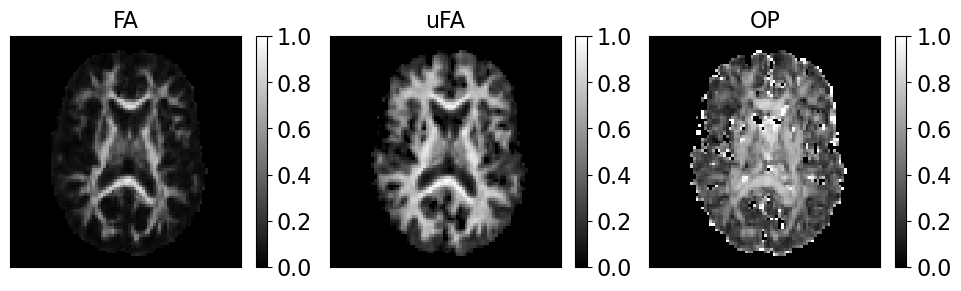

In [45]:
ufa2 = 15*kani / (10*kani + 12)
ufa2[ufa2<0] = 0
ufa = np.sqrt(ufa2)
OP = compute_OP(kani, fa)

fig1, ax = plt.subplots(1, 3, figsize=(12, 3),
                        subplot_kw={'xticks': [], 'yticks': []})

fig1.subplots_adjust(hspace=0.03, wspace=0.1)
cax0 = ax.flat[0].imshow(fa[:, :, 30].T,
                  origin='lower', cmap='gray',
                  vmin=0, vmax=1, interpolation='nearest')
ax.flat[0].set_title('FA', fontsize=16)

cax1 = ax.flat[1].imshow(ufa[:, :, 30].T,
                  origin='lower', cmap='gray',
                  vmin=0, vmax=1, interpolation='nearest')
ax.flat[1].set_title('uFA', fontsize=16)

cax2 = ax.flat[2].imshow(OP[:, :, 30].T,
                  origin='lower', cmap='gray',
                  vmin=0, vmax=1, interpolation='nearest')
ax.flat[2].set_title('OP', fontsize=16)

cbar = fig1.colorbar(cax0, ax=ax.flat[0])
cbar.ax.tick_params(labelsize=16) 

cbar = fig1.colorbar(cax1, ax=ax.flat[1])
cbar.ax.tick_params(labelsize=16) 

cbar = fig1.colorbar(cax2, ax=ax.flat[2])
cbar.ax.tick_params(labelsize=16) 